In [3]:
import matplotlib.pyplot as plt
import numpy as np

import fastf1


session = fastf1.get_session(2020, 'Monza', 'Q')
session.load()

lap = session.laps.pick_fastest()
pos = lap.get_pos_data()

circuit_info = session.get_circuit_info()

req         WARNING 	DEFAULT CACHE ENABLED! (96.04 MB) C:\Users\aless\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['44', '77', '55', '11', '33', '4', '3', '18', '23', '10', '26', '31', '16', '7', '20', '8', '5', '99', '63', '6']


In [4]:
def rotate(xy, *, angle):
    rot_mat = np.array([[np.cos(angle), np.sin(angle)],
                        [-np.sin(angle), np.cos(angle)]])
    return np.matmul(xy, rot_mat)

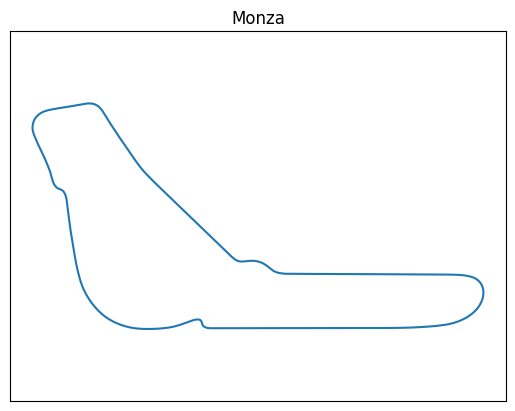

In [5]:
# Get an array of shape [n, 2] where n is the number of points and the second
# axis is x and y.
track = pos.loc[:, ('X', 'Y')].to_numpy()

# Convert the rotation angle from degrees to radian.
track_angle = circuit_info.rotation / 180 * np.pi

# Rotate and plot the track map.
rotated_track = rotate(track, angle=track_angle)
rotated_track = np.vstack([rotated_track, rotated_track[0]])  # close the loop

plt.plot(rotated_track[:, 0], rotated_track[:, 1])

plt.title(session.event['Location'])
plt.xticks([])
plt.yticks([])
plt.axis('equal')
plt.show()

Circuit length from telemetry: 5784 m
Scale factor: 0.1003
Total track length (native): 57653
Total track length (meters): 5784 m
Scale factor: 0.1003
Centerline points (every 5m): 1156


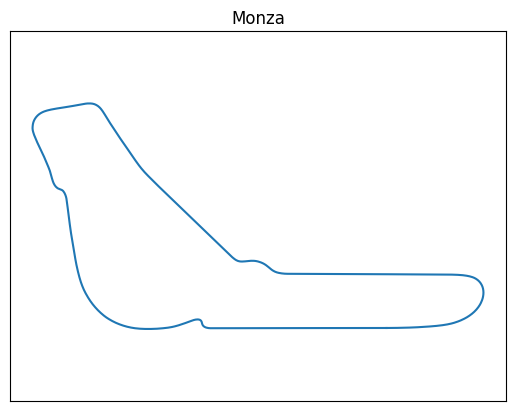

In [6]:
from scipy.interpolate import splprep, splev

track = rotated_track

tck, u = splprep([track[:, 0], track[:, 1]], s=0, per=True)

# Compute total length in native units
u_fine = np.linspace(0, 1, 10000)
x_fine, y_fine = splev(u_fine, tck)
pts_fine = np.column_stack([x_fine, y_fine])
total_length = np.sum(np.linalg.norm(np.diff(pts_fine, axis=0), axis=1))

# Scale to meters
lap = session.laps.pick_fastest()
circuit_length_m = lap.get_telemetry().add_distance()['Distance'].max()
scale = circuit_length_m / total_length

print(f"Circuit length from telemetry: {circuit_length_m:.0f} m")
print(f"Scale factor: {scale:.4f}")

# Resample every 5 meters
n_points = int(circuit_length_m / 5)
u_uniform = np.linspace(0, 1, n_points)
x_res, y_res = splev(u_uniform, tck)
centerline = np.column_stack([x_res, y_res]) * scale

print(f"Total track length (native): {total_length:.0f}")
print(f"Total track length (meters): {circuit_length_m:.0f} m")
print(f"Scale factor: {scale:.4f}")
print(f"Centerline points (every 5m): {len(centerline)}")

plt.plot(centerline[:, 0], centerline[:, 1])
plt.title(session.event['Location'])
plt.xticks([])
plt.yticks([])
plt.axis('equal')
plt.show()

In [7]:
def plot_tangent_arrows(centerline, tangents, every=20):

    plt.figure(figsize=(8, 8))
    plt.plot(centerline[:, 0], centerline[:, 1], 'k-')

    plt.quiver(
        centerline[::every, 0],
        centerline[::every, 1],
        tangents[::every, 0],
        tangents[::every, 1],
        scale=30
    )

    plt.axis('equal')
    plt.title('Tangent Vectors')
    plt.show()

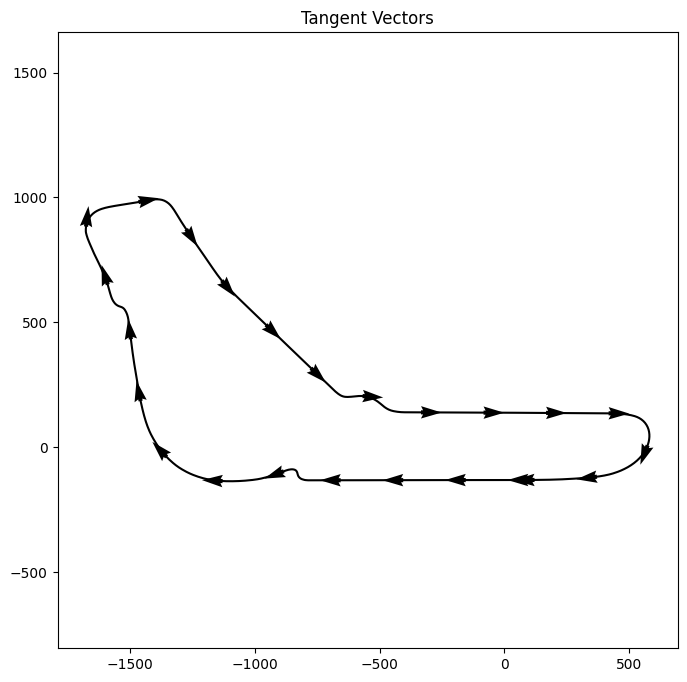

In [ ]:
# --- Compute unit tangent vectors at each centerline point ---
dx, dy = splev(u_uniform, tck, der=1)
tangents_raw = np.column_stack([dx, dy]) * scale
norms = np.linalg.norm(tangents_raw, axis=1, keepdims=True)
tangents = tangents_raw / norms

plot_tangent_arrows(
    centerline, tangents,
    every=50,   # draw every 10th tangent
)

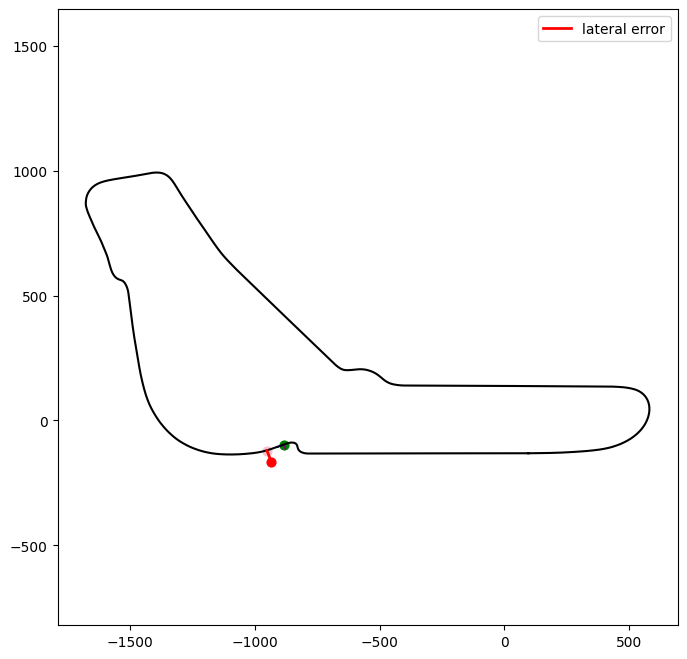

In [41]:
p = centerline[200]
agent_pos = np.array(p + [-50, -70])

tangent = tangents[200]
normal = np.array([-tangent[1], tangent[0]])

error_vec = agent_pos - p

forward = np.dot(error_vec, tangent)
lateral = np.dot(error_vec, normal)

foot = p + forward * tangent

plt.figure(figsize=(8, 8))

plt.plot(centerline[:, 0], centerline[:, 1], 'k')

plt.scatter(p[0], p[1], c="green", s=40)
plt.scatter(agent_pos[0], agent_pos[1], c="red", s=40)
plt.scatter(foot[0], foot[1], c="pink", s=40)

# tangent
plt.arrow(p[0], p[1], 30*tangent[0], 30*tangent[1], color="blue")

# normal
plt.arrow(p[0], p[1], 20*normal[0], 20*normal[1], color="purple")

# TRUE lateral error (perpendicular to tangent)
plt.plot(
    [agent_pos[0], foot[0]],
    [agent_pos[1], foot[1]],
    'r-',
    linewidth=2,
    label="lateral error"
)

plt.axis('equal')
plt.legend()
plt.show()